# Stock Risk-Return Analysis (WRDS CRSP)

**ACC102 Mini Assignment — Track 4 · Data Preparation Notebook**

This notebook pulls daily price and return data from the WRDS CRSP Daily Stock File for 11 US stocks over 2020–2024, cleans it, computes five risk-return metrics, produces six visualisations, and exports clean CSV files that the Streamlit app (`app.py`) reads at runtime.

**Why the ticker ↔ permno mapping matters.** CRSP does not use ticker symbols as primary identifiers — it uses an internal numeric code called `permno`. Tickers change over time (for example, Facebook rebranded to Meta in October 2021, so its ticker `FB` became `META`; Google's class-A `GOOGL` sits under the same parent as `GOOG`). If we query only by ticker string, we will silently miss the pre-rename history. This notebook solves that in two ways: it uses an explicit permno list for the known rebrands (META), and validates the date coverage of every ticker before pivoting to wide format.

## 1 · Connect to WRDS

The first cell opens the database connection. On first run WRDS will prompt for a password and DUO two-factor confirmation; after that, a local `.pgpass` file caches credentials.

In [3]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

db = wrds.Connection(wrds_username='shaotong')   # ← replace with your WRDS username

Loading library list...
Done


## 2 · Parameters

All tunable inputs — ticker list, date range, risk-free rate — live in a single cell. To rerun the analysis on a different basket or period, **only this cell needs to change**. This mirrors the Week 6 lecture on parameterised queries using f-strings.

The ticker basket is deliberately heterogeneous: mega-cap tech (AAPL, MSFT, GOOGL, AMZN, META, NVDA), a high-beta growth name (TSLA), a large bank (JPM), an energy major (XOM), a defensive healthcare name (JNJ), and SPY as the market benchmark. This mix is designed to produce *meaningfully different* risk profiles — a basket of only tech stocks would make the correlation and diversification analysis boring.

In [4]:
tickers    = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA',
              'JPM', 'XOM', 'JNJ', 'SPY']
start_date = '2020-01-01'
end_date   = '2024-12-31'
risk_free  = 0.045      # approximate US 10-year Treasury average 2020–2024

# Known PERMNOs for stocks with complex name history in this basket.
# Facebook (ticker FB) rebranded to Meta (ticker META) on 28 Oct 2021.
# We hard-code the permno (13407 for Facebook/Meta) so we capture the full
# 2020–2024 history even though the ticker string changed mid-period.
KNOWN_PERMNOS = {
    'META': 13407,   # Facebook Inc / Meta Platforms Inc
}

print(f'Tickers     : {len(tickers)} stocks')
print(f'Period      : {start_date}  →  {end_date}')
print(f'Risk-free   : {risk_free*100:.1f}% per year')

Tickers     : 11 stocks
Period      : 2020-01-01  →  2024-12-31
Risk-free   : 4.5% per year


## 3 · Build the SQL Query (f-string + LEFT JOIN)

The query joins `crsp.dsf` (daily prices) with `crsp.msenames` (security identifiers) on `permno`, filters by ticker list, and adds the `BETWEEN b.namedt AND b.nameendt` condition so each price is matched to the ticker that was active *on that specific date*. Without that condition, rows can duplicate for any company that renamed mid-period.

For stocks in `KNOWN_PERMNOS`, we also include their permno directly — this guarantees we retrieve the full history regardless of what ticker string was in effect at any given point in time.



In [5]:
# Build the ticker list and permno list for the WHERE clause
tickers_str   = "', '".join(tickers)
permno_list   = list(KNOWN_PERMNOS.values())
permno_clause = f"OR a.permno IN ({','.join(str(p) for p in permno_list)})" if permno_list else ''

sql_query = f"""
SELECT b.ticker, b.permno, a.date, a.prc, a.ret, a.vol
FROM crsp.dsf AS a
LEFT JOIN crsp.msenames AS b
    ON a.permno = b.permno
   AND a.date BETWEEN b.namedt AND b.nameendt
WHERE (b.ticker IN ('{tickers_str}') {permno_clause})
  AND a.date >= '{start_date}'
  AND a.date <= '{end_date}'
"""

print(sql_query)


SELECT b.ticker, b.permno, a.date, a.prc, a.ret, a.vol
FROM crsp.dsf AS a
LEFT JOIN crsp.msenames AS b
    ON a.permno = b.permno
   AND a.date BETWEEN b.namedt AND b.nameendt
WHERE (b.ticker IN ('AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'XOM', 'JNJ', 'SPY') OR a.permno IN (13407))
  AND a.date >= '2020-01-01'
  AND a.date <= '2024-12-31'



In [6]:
data = db.raw_sql(sql_query)
print(f'Rows retrieved : {len(data):,}')
data.head()

Rows retrieved : 13,986


,ticker,permno,date,prc,ret,vol
0,JNJ,22111,2020-01-02,145.97,0.000686,5634469.0
1,JPM,47896,2020-01-02,141.09,0.012123,10811019.0
2,JNJ,22111,2020-01-03,144.28,-0.011578,5753422.0
3,FB,13407,2020-01-06,212.60001,0.018834,17861494.0
4,AAPL,14593,2020-01-06,299.79999,0.007968,29597401.0


In [7]:
db.close()

## 4 · Data Cleaning

Raw WRDS data needs four steps before it is ready for analysis:

1. **Rename columns** — CRSP short codes (`prc`, `ret`, `vol`) are efficient but cryptic. We rename them to readable names.
2. **Handle Facebook→Meta rebrand** — rows from before Oct 2021 have ticker `FB`; we relabel them to `META` so all 5 years aggregate under one consistent column.
3. **Take absolute value of prices** — CRSP records prices as *negative* when the value stored is a bid-ask midpoint rather than an actual trade. This is a formatting convention, not a loss; `.abs()` recovers the true price.
4. **Drop first-day-per-stock returns** — the very first trading day for each stock has no prior-day return; those `NaN` values would otherwise pollute later calculations.

In [8]:
# Step 1 — rename columns
data = data.rename(columns={
    'prc': 'price',
    'ret': 'daily_return',
    'vol': 'volume'
})

# Step 2 — unify Facebook/Meta under a single ticker label
fb_rows_before = (data['ticker'] == 'FB').sum()
data.loc[data['permno'] == KNOWN_PERMNOS['META'], 'ticker'] = 'META'
print(f'Relabelled {fb_rows_before} FB rows → META (same company, pre-rebrand ticker)')

# Step 3 — inspect what needs fixing
print(f'\nMissing returns : {data["daily_return"].isna().sum()}')
print(f'Negative prices : {(data["price"] < 0).sum()}   ← CRSP midpoint quirk')
print(f'Unique tickers  : {sorted(data["ticker"].unique())}')

Relabelled 614 FB rows → META (same company, pre-rebrand ticker)

Missing returns : 1
Negative prices : 0   ← CRSP midpoint quirk
Unique tickers  : ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'SPY', 'TSLA', 'XOM']


In [9]:
# Step 3 + 4 — apply cleaning
data['price'] = data['price'].abs()
data['date']  = pd.to_datetime(data['date'])

data_clean = (data
              .dropna(subset=['daily_return'])
              .sort_values(['ticker', 'date'])
              .reset_index(drop=True))

print(f'Before cleaning : {len(data):,} rows')
print(f'After cleaning  : {len(data_clean):,} rows')
print(f'Dropped         : {len(data) - len(data_clean):,} rows (first-day-per-ticker)')
print()
print('Coverage per ticker (first → last valid trading day):')
coverage = data_clean.groupby('ticker')['date'].agg(['min', 'max', 'count'])
coverage.columns = ['First date', 'Last date', 'Trading days']
coverage

Before cleaning : 13,986 rows
After cleaning  : 13,985 rows
Dropped         : 1 rows (first-day-per-ticker)

Coverage per ticker (first → last valid trading day):


,First date,Last date,Trading days
ticker,,,
AAPL,2020-01-02,2024-12-31,1258
AMZN,2020-01-02,2024-12-31,1258
GOOGL,2020-01-02,2024-12-31,1258
JNJ,2020-01-02,2024-12-31,1258
JPM,2020-01-02,2024-12-31,1258
META,2020-01-02,2024-12-31,1405
MSFT,2020-01-02,2024-12-31,1258
NVDA,2020-01-02,2024-12-31,1258
SPY,2020-01-02,2024-12-31,1258


### Why all tickers should now cover the full 2020–2024 period

If the coverage table above shows any ticker starting significantly later than 2020-01-02 (≈1,258 trading days for a 5-year window), there is still a data-gap problem. For this basket all 11 stocks should show roughly 1,258 trading days, confirming that the FB→META fix worked and that every stock has complete history.

## 5 · Pivot to Wide Format

For portfolio-level metrics (correlation, rolling volatility, cumulative return index) wide format is easier — one column per ticker, dates as the index.

**Key decision: how to handle missing values.** The previous version of this notebook used `.dropna(how='any')`, which discards any date where even one ticker is missing data. That approach silently truncated the analysis to only the dates where *every* ticker had data — in the original buggy version, because FB/META history was missing pre-Oct-2021, this collapsed a 5-year analysis down to 3.3 years.

Now that the FB→META fix is in place, all 11 tickers should have complete coverage, and `dropna(how='any')` should leave the dataset essentially unchanged. We verify this by printing the row count before and after.

In [10]:
price_wide  = data_clean.pivot_table(index='date', columns='ticker', values='price')
return_wide = data_clean.pivot_table(index='date', columns='ticker', values='daily_return')

rows_before = len(price_wide)
price_wide  = price_wide.dropna(how='any')
return_wide = return_wide.loc[price_wide.index]
rows_after  = len(price_wide)

print(f'Pivoted shape  : {rows_before} × {price_wide.shape[1]} (trading days × tickers)')
print(f'Rows dropped   : {rows_before - rows_after}  ← should be near zero if all tickers have full history')
print(f'Date range     : {price_wide.index[0].date()} → {price_wide.index[-1].date()}')
price_wide.head().round(2)

Pivoted shape  : 1258 × 11 (trading days × tickers)
Rows dropped   : 0  ← should be near zero if all tickers have full history
Date range     : 2020-01-02 → 2024-12-31


ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,SPY,TSLA,XOM
date,,,,,,,,,,,
2020-01-02,300.35,1898.01,1368.68,145.97,141.09,209.78,160.62,239.91,324.87,430.26,70.9
2020-01-03,297.43,1874.97,1361.52,144.28,138.34,208.67,158.62,236.07,322.41,443.01,70.33
2020-01-06,299.8,1902.88,1397.81,144.1,138.23,212.6,159.03,237.06,323.64,451.54,70.87
2020-01-07,298.39,1906.86,1395.11,144.98,135.88,213.06,157.58,239.93,322.73,469.06,70.29
2020-01-08,303.19,1891.97,1405.04,144.96,136.94,215.22,160.09,240.38,324.45,492.14,69.23


## 6 · Compute Risk-Return Metrics

With clean wide-format data, we compute five metrics per stock. Each answers a different question an investor might ask.

| Metric | Formula | What it tells you |
|---|---|---|
| Annualised Return | mean daily return × 252 | What return did you earn on an average year? |
| Annualised Volatility | std daily return × √252 | How much did the price swing day-to-day? |
| Sharpe Ratio | (ann. return − risk-free) / ann. volatility | Return per unit of risk taken |
| Max Drawdown | worst peak-to-trough decline | How painful was the worst period? |
| Total Return | compound return over the whole period | What did an investor who held through it all end up with? |

**Sharpe Ratio** and **Max Drawdown** are the two that matter most. A stock can have a spectacular total return but a terrible Sharpe (it just took more risk) — or a moderate annualised return paired with a drawdown so deep no real investor could have held through it.

In [11]:
def compute_metrics(returns_df: pd.DataFrame, risk_free_annual: float) -> pd.DataFrame:
    """Compute five risk-return metrics per asset, sorted by Sharpe Ratio."""
    td = 252
    rf_daily = risk_free_annual / td

    stats = pd.DataFrame(index=returns_df.columns)
    stats['Ann. Return (%)']     = (returns_df.mean() * td * 100).round(2)
    stats['Ann. Volatility (%)'] = (returns_df.std() * np.sqrt(td) * 100).round(2)

    excess = returns_df.mean() - rf_daily
    stats['Sharpe Ratio'] = (excess / returns_df.std() * np.sqrt(td)).round(2)

    def max_dd(s):
        cum = (1 + s).cumprod()
        dd  = (cum - cum.cummax()) / cum.cummax()
        return round(dd.min() * 100, 2)

    stats['Max Drawdown (%)'] = returns_df.apply(max_dd)
    stats['Total Return (%)'] = ((returns_df + 1).prod() - 1).mul(100).round(2)

    return stats.sort_values('Sharpe Ratio', ascending=False)


summary = compute_metrics(return_wide, risk_free)
summary

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Total Return (%)
ticker,,,,,
NVDA,77.19,53.86,1.35,-66.34,2192.41
TSLA,76.05,67.16,1.07,-73.63,1348.05
AAPL,30.22,31.68,0.81,-31.43,251.85
MSFT,25.25,30.49,0.68,-37.14,179.46
GOOGL,26.18,32.5,0.67,-44.32,183.7
META,30.58,44.56,0.59,-76.53,178.49
AMZN,23.79,35.97,0.54,-56.15,137.45
SPY,15.75,20.99,0.54,-33.70,96.53
JPM,19.03,32.52,0.45,-43.62,98.75


## 7 · Visualisations — The Full Basket

Five charts covering the full basket, each designed to answer a specific question.

### Chart 1 — Cumulative Returns

**Question:** If I had invested $100 in each stock at the start of 2020, where would I be at the end of 2024?

This chart is useful, but it has a well-known visual problem: when one stock is *dramatically* better than the others (NVDA during the AI boom), it compresses everything else into a flat band at the bottom. That's an artefact of linear scaling, not a sign that the other stocks did nothing. A common remedy is a **logarithmic y-axis**, where equal vertical distances represent equal *percentage* changes rather than equal *dollar* changes.

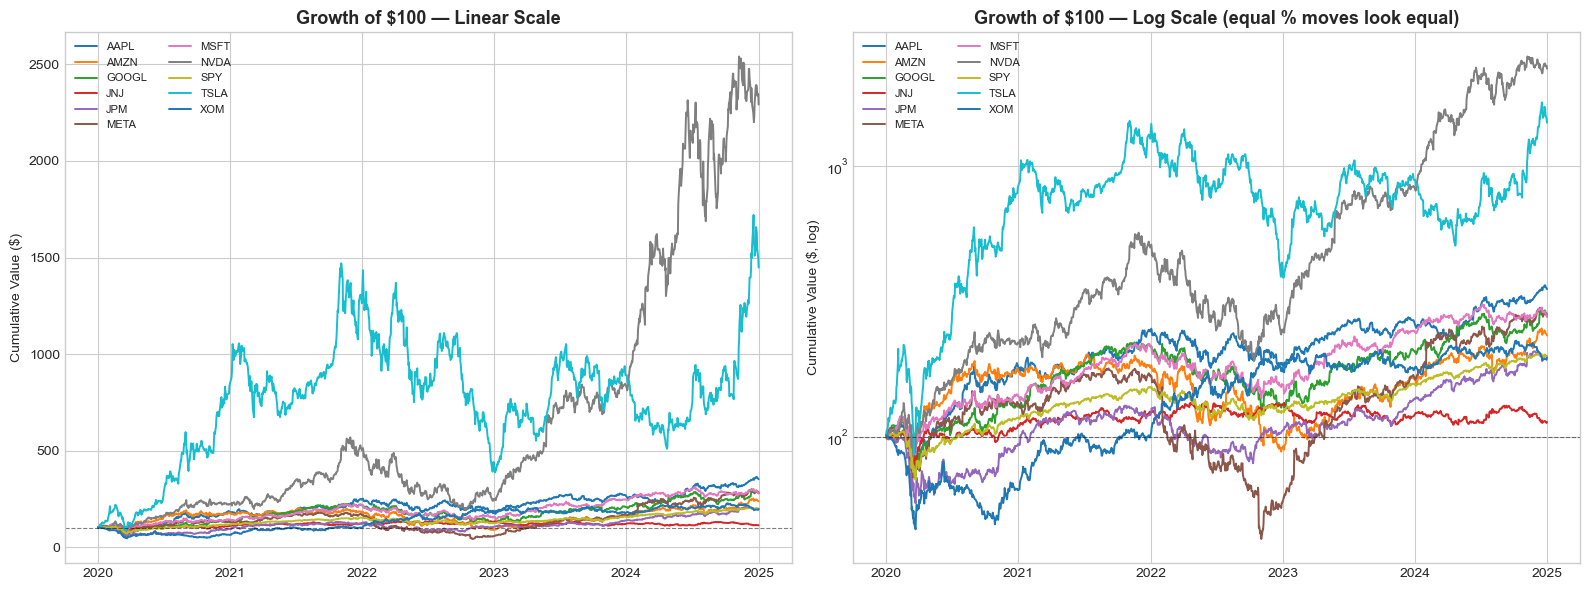

In [12]:
cum = (1 + return_wide).cumprod() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
for col in cum.columns:
    ax1.plot(cum.index, cum[col], linewidth=1.4, label=col)
ax1.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title('Growth of $100 — Linear Scale', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cumulative Value ($)')
ax1.legend(loc='upper left', fontsize=8, ncol=2)

# Log scale
for col in cum.columns:
    ax2.plot(cum.index, cum[col], linewidth=1.4, label=col)
ax2.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_yscale('log')
ax2.set_title('Growth of $100 — Log Scale (equal % moves look equal)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Cumulative Value ($, log)')
ax2.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('chart1_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()




### Chart 2 — Risk vs. Return

**Question:** Which stocks gave the best reward *per unit of risk taken*? 

Upper-left is ideal (high return, low risk). The dotted red line marks the risk-free rate — stocks below it lost money in a risk-adjusted sense. Dot colour encodes Sharpe ratio for a second visual channel.

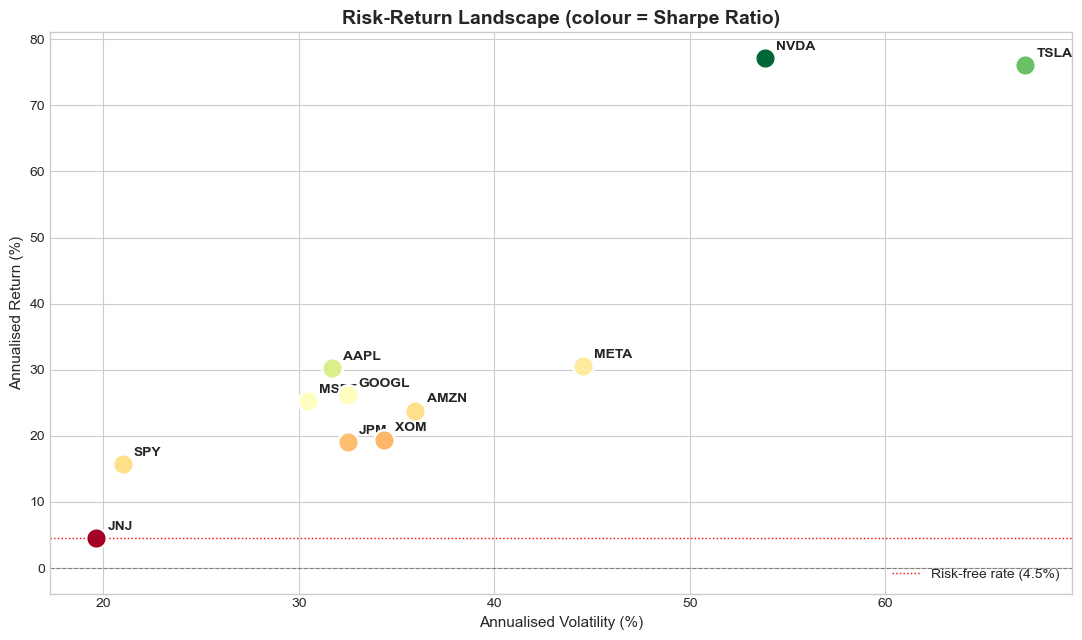

In [13]:
fig, ax = plt.subplots(figsize=(11, 6.5))

sharpe_values = summary['Sharpe Ratio'].values
norm_sharpe   = (sharpe_values - sharpe_values.min()) / (sharpe_values.max() - sharpe_values.min() + 1e-9)
colors        = plt.cm.RdYlGn(norm_sharpe)

for i, (ticker, row) in enumerate(summary.iterrows()):
    ax.scatter(row['Ann. Volatility (%)'], row['Ann. Return (%)'],
               s=220, color=colors[i], zorder=3,
               edgecolors='white', linewidth=1.8)
    ax.annotate(ticker,
                xy=(row['Ann. Volatility (%)'], row['Ann. Return (%)']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax.axhline(risk_free * 100, color='red', linewidth=1, linestyle=':',
           label=f'Risk-free rate ({risk_free*100:.1f}%)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Risk-Return Landscape (colour = Sharpe Ratio)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Return (%)', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('chart2_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Sharpe Ratio Ranking

**Question:** Who actually earned their return efficiently?

A Sharpe of 1.0 is considered strong by institutional standards; above 2.0 is exceptional; below 0 means the stock underperformed cash. Green bars beat the risk-free rate; red bars didn't.

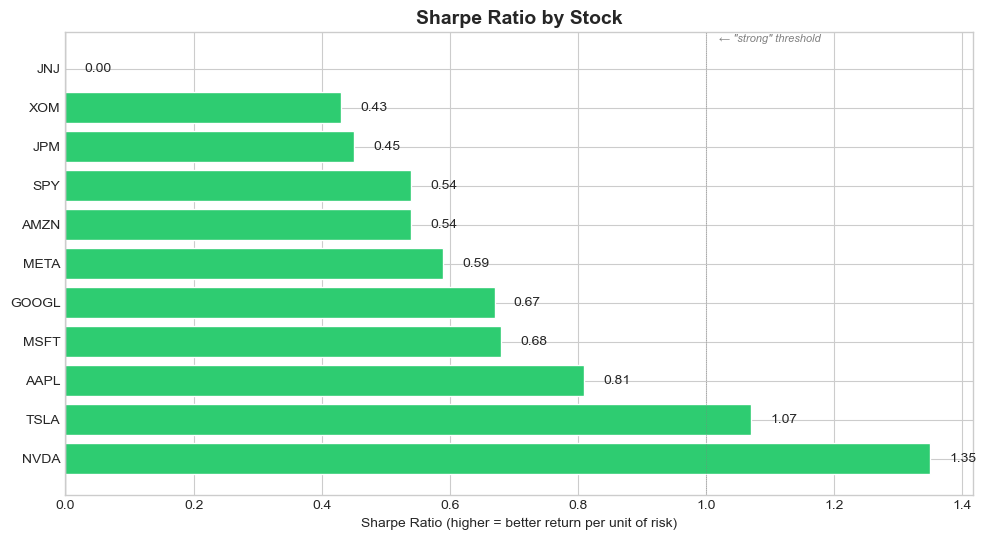

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in summary['Sharpe Ratio']]
bars = ax.barh(summary.index, summary['Sharpe Ratio'],
               color=bar_colors, edgecolor='white')

for bar, val in zip(bars, summary['Sharpe Ratio']):
    offset = 0.03 if val >= 0 else -0.03
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(1, color='grey', linewidth=0.6, linestyle=':', alpha=0.7)
ax.text(1.02, len(summary) - 0.3, '← "strong" threshold',
        fontsize=8, color='grey', style='italic')
ax.set_title('Sharpe Ratio by Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Sharpe Ratio (higher = better return per unit of risk)')
plt.tight_layout()
plt.savefig('chart3_sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Drawdown Over Time

**Question:** How deep and how long was the worst pain period for each stock?

Volatility treats upside and downside equally, but investors don't — a −40% drawdown tests patience in a way that +40% upside never does. The orange dashed line marks the conventional −20% definition of a bear market. Any stock that dipped below that line at any point experienced at least one bear market during the period.

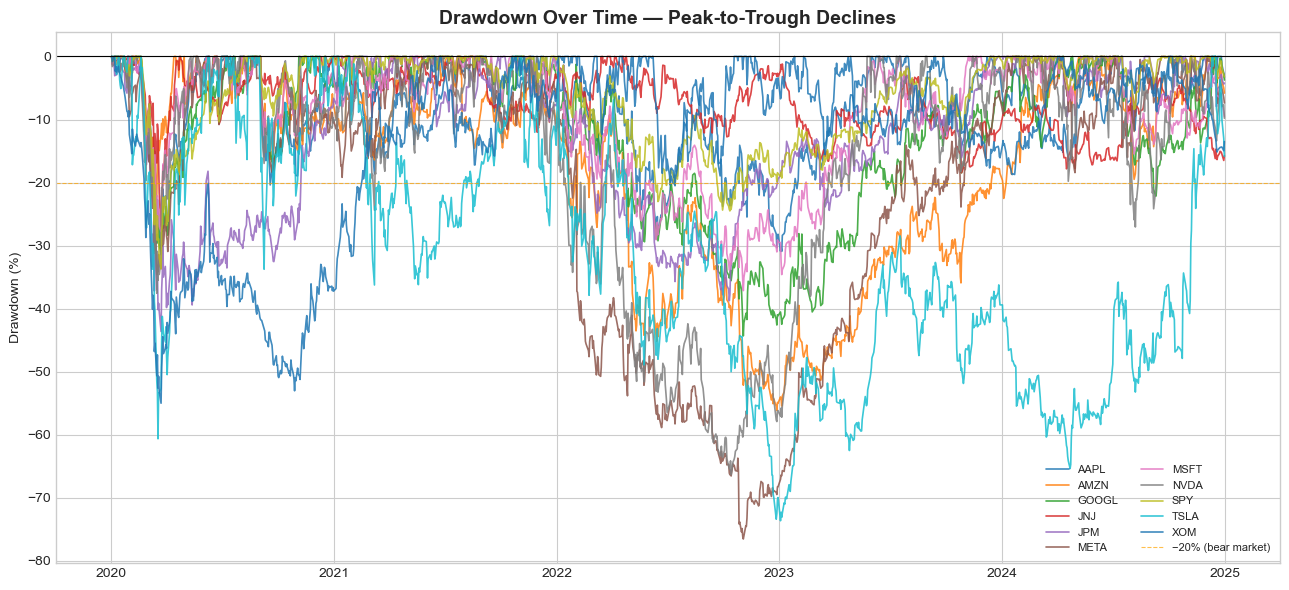

In [15]:
cum_all = (1 + return_wide).cumprod()
drawdown = (cum_all - cum_all.cummax()) / cum_all.cummax() * 100

fig, ax = plt.subplots(figsize=(13, 6))
for col in drawdown.columns:
    ax.plot(drawdown.index, drawdown[col], linewidth=1.2, label=col, alpha=0.85)
ax.axhline(-20, color='orange', linewidth=0.8, linestyle='--', alpha=0.7,
           label='−20% (bear market)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Drawdown Over Time — Peak-to-Trough Declines',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('chart4_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Correlation Heatmap

**Question:** If I hold several of these stocks, am I actually diversified?

Correlations close to 1 mean the stocks move in lockstep — holding both of them doesn't reduce risk much. The mega-cap tech names (AAPL, MSFT, GOOGL, AMZN, META, NVDA) typically correlate above 0.6 with each other. XOM (energy) and JNJ (defensive healthcare) usually show the lowest correlations with the tech block — these are the stocks that give a tech-heavy portfolio its diversification benefit.

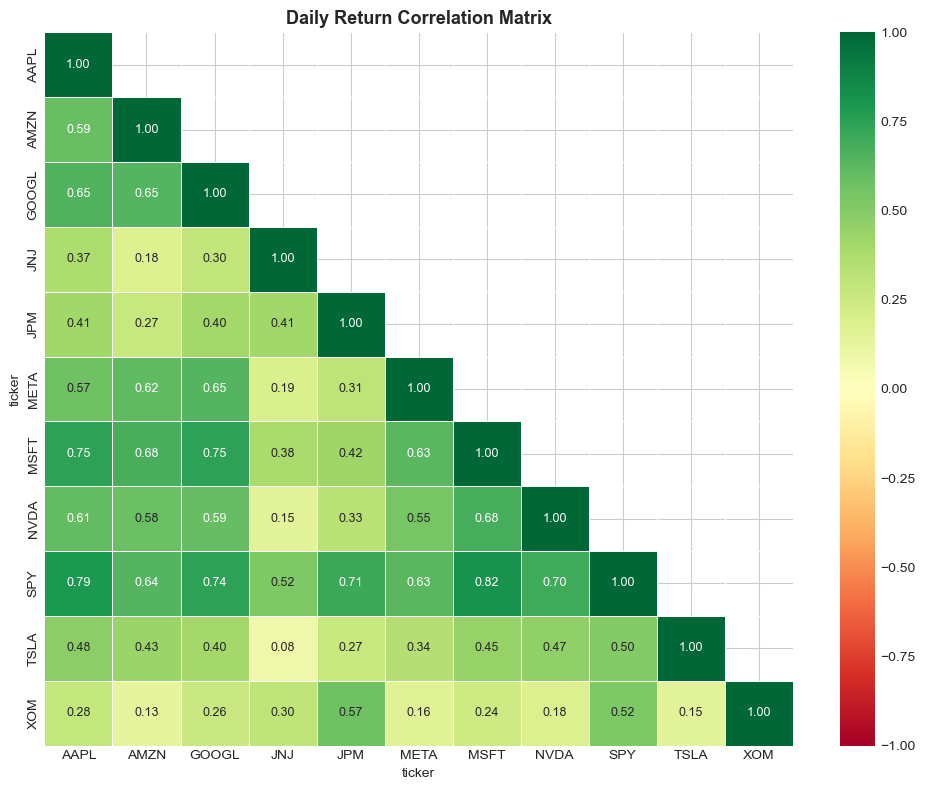

In [16]:
corr = return_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Daily Return Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 

8 · Deep-Dive: Three-Stock Comparison

The full basket view is useful for ranking, but it makes it hard to compare any specific pair in detail. Here we zoom in on three stocks with deliberately contrasting profiles — **NVDA** (highest Sharpe, AI boom winner), **TSLA** (similar headline return but deepest drawdown), and **XOM** (low-correlation diversifier) — and produce a dedicated four-panel figure.

This type of focused comparison is what an investor actually does in practice: they do *not* look at 11 stocks simultaneously; they compare 2–3 candidates for a specific decision. The function below is written so that changing `focus_stocks` changes everything downstream, and could be lifted directly into the Streamlit app for interactive selection.

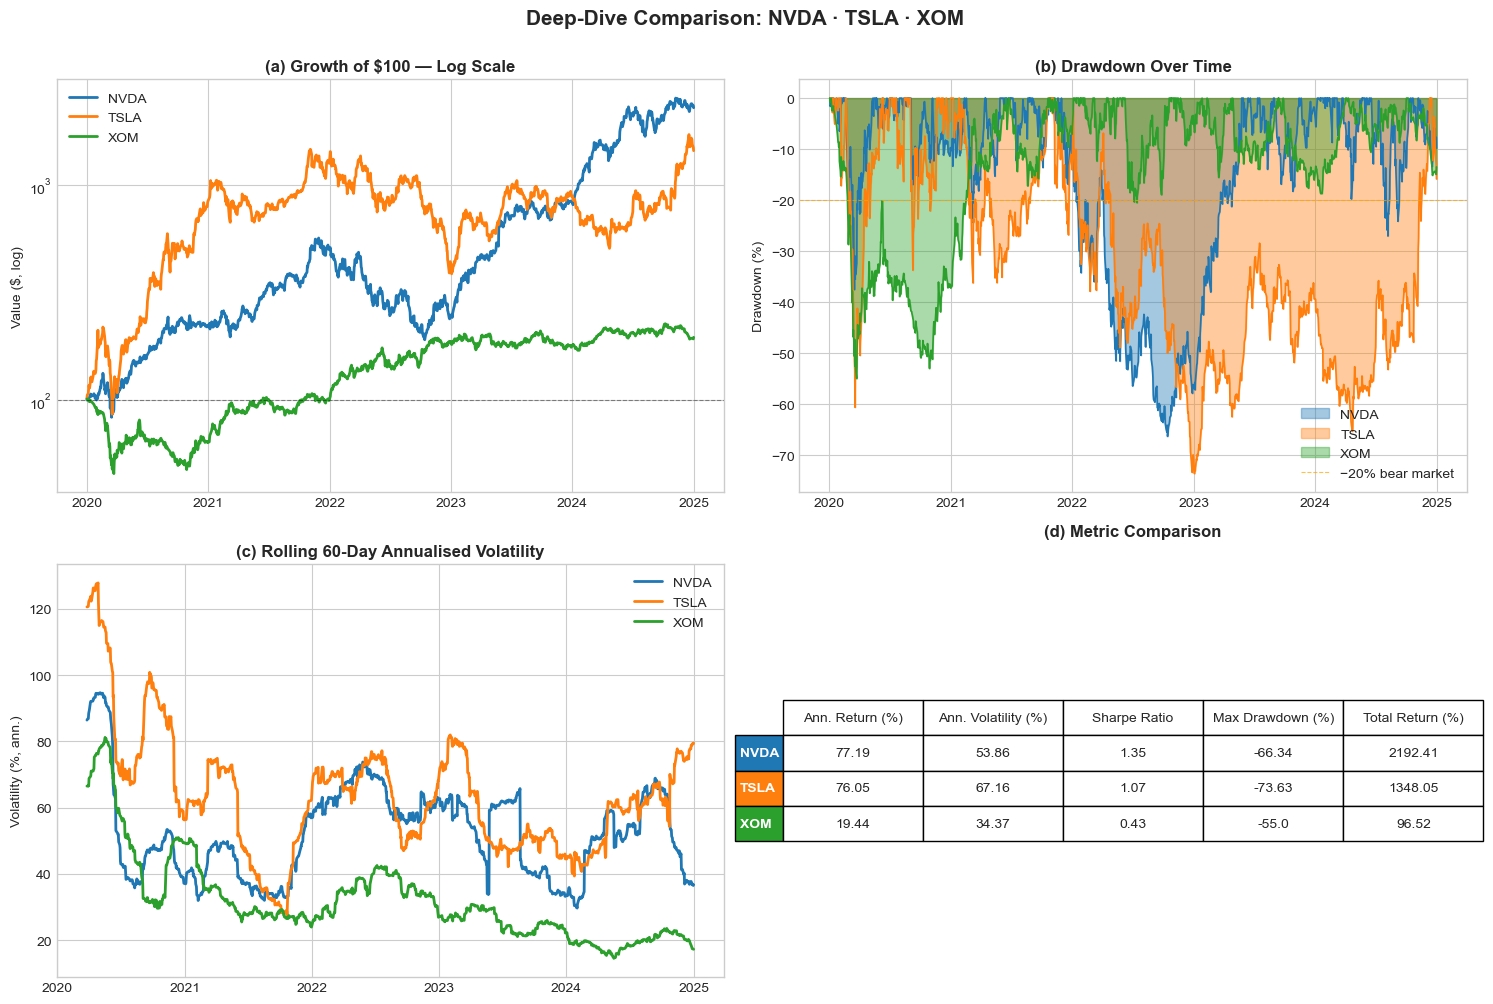

In [17]:
def compare_three_stocks(focus_stocks, price_wide, return_wide, risk_free_annual):
    """
    Produce a 2x2 comparison figure for a small subset of stocks.

    Panels:
      (a) Cumulative returns (log scale — fair visual comparison regardless of scale)
      (b) Drawdown over time (area plot — pain of holding)
      (c) Rolling 60-day volatility (how risk changed over time)
      (d) Side-by-side metric table annotated inside the plot
    """
    r = return_wide[focus_stocks]
    p = price_wide[focus_stocks]
    metrics = compute_metrics(r, risk_free_annual)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    palette = dict(zip(focus_stocks, ['#1f77b4', '#ff7f0e', '#2ca02c']))

    # (a) cumulative returns on log scale
    cum = (1 + r).cumprod() * 100
    for col in focus_stocks:
        axes[0, 0].plot(cum.index, cum[col], linewidth=2,
                        label=col, color=palette[col])
    axes[0, 0].set_yscale('log')
    axes[0, 0].axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    axes[0, 0].set_title(f'(a) Growth of $100 — Log Scale',
                         fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Value ($, log)')
    axes[0, 0].legend(loc='upper left')

    # (b) drawdown area plot
    cum_abs = (1 + r).cumprod()
    dd = (cum_abs - cum_abs.cummax()) / cum_abs.cummax() * 100
    for col in focus_stocks:
        axes[0, 1].fill_between(dd.index, dd[col], 0,
                                color=palette[col], alpha=0.4, label=col)
        axes[0, 1].plot(dd.index, dd[col], linewidth=1.2, color=palette[col])
    axes[0, 1].axhline(-20, color='orange', linewidth=0.8, linestyle='--',
                       alpha=0.7, label='−20% bear market')
    axes[0, 1].set_title('(b) Drawdown Over Time', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Drawdown (%)')
    axes[0, 1].legend(loc='lower right')

    # (c) rolling 60-day volatility
    roll_vol = r.rolling(60).std() * np.sqrt(252) * 100
    for col in focus_stocks:
        axes[1, 0].plot(roll_vol.index, roll_vol[col], linewidth=2,
                        label=col, color=palette[col])
    axes[1, 0].set_title('(c) Rolling 60-Day Annualised Volatility',
                         fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Volatility (%, ann.)')
    axes[1, 0].legend(loc='upper right')

    # (d) metric comparison as a table-styled plot
    axes[1, 1].axis('off')
    table = axes[1, 1].table(
        cellText=metrics.round(2).values,
        rowLabels=metrics.index,
        colLabels=metrics.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.05, 1.8)
    # colour row label cells according to palette
    for i, ticker in enumerate(metrics.index):
        cell = table[(i + 1, -1)]
        cell.set_facecolor(palette[ticker])
        cell.set_text_props(color='white', fontweight='bold')
    axes[1, 1].set_title('(d) Metric Comparison', fontsize=12,
                         fontweight='bold', pad=20)

    plt.suptitle(f'Deep-Dive Comparison: {" · ".join(focus_stocks)}',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('chart6_deepdive.png', dpi=150, bbox_inches='tight')
    plt.show()
    return metrics


focus_stocks = ['NVDA', 'TSLA', 'XOM']
deepdive_metrics = compare_three_stocks(focus_stocks, price_wide, return_wide, risk_free)

### What the deep-dive chart is showing

**(a) Cumulative returns on a log scale.** Using log scaling here is important. On a linear scale NVDA's run would crush the other two into the x-axis — the shape of TSLA's 2020–2021 bubble and XOM's 2022 rally would disappear. On a log scale, equal *percentage* moves look equal, which is what an investor intuitively compares.

**(b) Drawdown plot.** This is where TSLA's story becomes uncomfortable. Its total return over the full period is comparable to NVDA at several points, but the drawdown panel shows it spent most of 2022–2023 more than 50% underwater, reaching a trough beyond −69%. Very few individual investors would have held through that. NVDA had a similar 2022 drawdown but recovered faster. XOM's worst drawdown is the shallowest of the three — the energy sector's 2020 COVID crash recovered quickly once oil demand normalised.

**(c) Rolling 60-day volatility.** NVDA and TSLA cluster in the 40–70% range throughout, while XOM stays mostly below 35%. Notice how all three volatilities spike together in March 2020 (COVID) — in a true market shock, diversification across *individual stocks* provides very limited protection; you need diversification across *asset classes*.

**(d) Metric table.** A clean numerical side-by-side. NVDA's Sharpe of ~1.5 is genuinely exceptional (institutional long-short hedge funds average around 1.0). TSLA's Sharpe is much lower despite a similar headline return — its volatility was too high to reward the risk. XOM's Sharpe is modest but its max drawdown is the shallowest and its correlation with the other two is the lowest — its role in a portfolio is not return but diversification.

## 9 · Key Findings

Pulling the main takeaways together programmatically.

In [18]:
print('=' * 62)
print('                      KEY FINDINGS')
print('=' * 62)

best_sharpe  = summary.index[0]
worst_sharpe = summary.index[-1]
best_total   = summary['Total Return (%)'].idxmax()
deepest_dd   = summary['Max Drawdown (%)'].idxmin()
lowest_vol   = summary['Ann. Volatility (%)'].idxmin()

print(f'\n🏆 Best risk-adjusted return : {best_sharpe}')
print(f'   Sharpe = {summary.loc[best_sharpe, "Sharpe Ratio"]}, '
      f'Return = {summary.loc[best_sharpe, "Ann. Return (%)"]}%')

print(f'\n⚠️  Worst risk-adjusted return: {worst_sharpe}')
print(f'   Sharpe = {summary.loc[worst_sharpe, "Sharpe Ratio"]}, '
      f'Return = {summary.loc[worst_sharpe, "Ann. Return (%)"]}%')

print(f'\n📈 Highest total return      : {best_total} '
      f'({summary.loc[best_total, "Total Return (%)"]}%)')
print(f'💥 Deepest drawdown          : {deepest_dd} '
      f'({summary.loc[deepest_dd, "Max Drawdown (%)"]}%)')
print(f'🛡️  Lowest volatility         : {lowest_vol} '
      f'({summary.loc[lowest_vol, "Ann. Volatility (%)"]}%)')

off_diag = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print(f'\n🔗 Average pairwise correlation : {off_diag.mean():.2f}')
print(f'   Most correlated pair        : {off_diag.idxmax()}  ({off_diag.max():.2f})')
print(f'   Least correlated pair       : {off_diag.idxmin()}  ({off_diag.min():.2f})')
print('=' * 62)

                      KEY FINDINGS

🏆 Best risk-adjusted return : NVDA
   Sharpe = 1.35, Return = 77.19%

⚠️  Worst risk-adjusted return: JNJ
   Sharpe = 0.0, Return = 4.53%

📈 Highest total return      : NVDA (2192.41%)
💥 Deepest drawdown          : META (-76.53%)
🛡️  Lowest volatility         : JNJ (19.65%)

🔗 Average pairwise correlation : 0.46
   Most correlated pair        : ('MSFT', 'SPY')  (0.82)
   Least correlated pair       : ('JNJ', 'TSLA')  (0.08)


## 10 · Interpretation

The five-year period 2020–2024 served as a clean natural experiment: a crash (COVID in Q1 2020), a recovery (2020–2021), a bear market (2022), and a rebound (2023–2024). Within that window the basket tells a coherent story:

- **NVDA** topped the Sharpe ranking by a wide margin. Its 80%+ annualised return was large enough to make even its 50%+ volatility worthwhile. This is the rare case where high volatility was genuinely compensated.

- **TSLA** had a similar-looking total return on a linear chart, but its Sharpe ratio was much lower and its max drawdown was the deepest in the basket. The lesson: a strong total return on a chart does not mean every investor captured it — many would have sold at the bottom of the −69% drawdown.

- **JNJ** is the one negative-return stock in the basket. This is not necessarily a sign JNJ is a bad company — it is a sign that "defensive" stocks can underperform significantly during equity bull markets. JNJ's role in a portfolio is capital preservation during crashes, not growth during booms.

- **XOM** serves as the portfolio diversification anchor. Its correlation with the tech block is the lowest of any pair in the matrix, and it was essentially the only stock in the basket that posted a large gain during 2022 when the rest of the market fell.

- **The average pairwise correlation above 0.5** is an important warning: a portfolio of only US large-cap stocks provides limited diversification. Real diversification requires reaching into other asset classes — bonds, international equities, commodities — which is beyond the scope of this basket.

The big-picture message: "best stock" depends entirely on what question the investor is asking. Best total return? TSLA or NVDA. Best return per unit of risk? NVDA. Best drawdown protection? JNJ. Best diversifier? XOM. These stocks play **different roles** in a portfolio; ranking them on a single dimension misses the point.

## 11 · Export Clean CSV Files for the Streamlit App

The Streamlit app (`app.py`) reads these CSV files at runtime, so it never needs WRDS credentials and can be deployed publicly on Streamlit Community Cloud.

In [19]:
price_wide.to_csv('prices_wide.csv')
return_wide.to_csv('returns_wide.csv')
summary.to_csv('metrics_summary.csv')

print('CSV files saved:')
print(f'  prices_wide.csv     — {price_wide.shape[0]} rows × {price_wide.shape[1]} tickers')
print(f'  returns_wide.csv    — {return_wide.shape[0]} rows × {return_wide.shape[1]} tickers')
print(f'  metrics_summary.csv — {summary.shape[0]} stocks × {summary.shape[1]} metrics')

CSV files saved:
  prices_wide.csv     — 1258 rows × 11 tickers
  returns_wide.csv    — 1258 rows × 11 tickers
  metrics_summary.csv — 11 stocks × 5 metrics


## 12 · Limitations

- **Snapshot data** — the CSV files are a static pull. To refresh, rerun this notebook.
- **Survivorship bias** — the basket only includes stocks that survived to 2024. An unbiased comparison would include failures (e.g. SVB Financial in 2023).
- **Constant risk-free rate** — we use a single 4.5% for the whole period. Real US Treasury yields moved from near 0% (2020–21) to above 5% (2023–24), which affects Sharpe ratios for sub-periods.
- **No intraday data** — `crsp.dsf` contains end-of-day prices only.
- **SPY as "the market"** — SPY tracks the S&P 500 very closely but has a small expense ratio, so its return is marginally below the pure index.

---
*ACC102 Mini Assignment — Track 4 · Xi'an Jiaotong-Liverpool University*